In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
# Load Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

columns = [
'ID','Diagnosis',
'Radius','Texture','Perimeter','Area','Smoothness',
'Compactness','Concavity','ConcavePoints','Symmetry',
'FractalDimension','Radius_SE','Texture_SE','Perimeter_SE',
'Area_SE','Smoothness_SE','Compactness_SE','Concavity_SE',
'ConcavePoints_SE','Symmetry_SE','FractalDimension_SE',
'Radius_W','Texture_W','Perimeter_W','Area_W',
'Smoothness_W','Compactness_W','Concavity_W',
'ConcavePoints_W','Symmetry_W','FractalDimension_W'
]

df = pd.read_csv(url, names=columns)
print(df.head())

         ID Diagnosis  Radius  Texture  Perimeter    Area  Smoothness  \
0    842302         M   17.99    10.38     122.80  1001.0     0.11840   
1    842517         M   20.57    17.77     132.90  1326.0     0.08474   
2  84300903         M   19.69    21.25     130.00  1203.0     0.10960   
3  84348301         M   11.42    20.38      77.58   386.1     0.14250   
4  84358402         M   20.29    14.34     135.10  1297.0     0.10030   

   Compactness  Concavity  ConcavePoints  ...  Radius_W  Texture_W  \
0      0.27760     0.3001        0.14710  ...     25.38      17.33   
1      0.07864     0.0869        0.07017  ...     24.99      23.41   
2      0.15990     0.1974        0.12790  ...     23.57      25.53   
3      0.28390     0.2414        0.10520  ...     14.91      26.50   
4      0.13280     0.1980        0.10430  ...     22.54      16.67   

   Perimeter_W  Area_W  Smoothness_W  Compactness_W  Concavity_W  \
0       184.60  2019.0        0.1622         0.6656       0.7119   
1   

In [3]:
# Select Two Features
X = df[['Radius','Texture']]

# Convert Target Labels
y = df['Diagnosis'].map({'M':1,'B':0})

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [4]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Class Probabilities
prob = model.predict_proba(X_test)
print("\nPredicted Class Probabilities\n")
print(prob[:10])


Predicted Class Probabilities

[[9.07852364e-01 9.21476363e-02]
 [1.85716044e-02 9.81428396e-01]
 [3.71667302e-01 6.28332698e-01]
 [9.27015037e-01 7.29849634e-02]
 [9.81578943e-01 1.84210572e-02]
 [8.20532996e-04 9.99179467e-01]
 [1.12393789e-03 9.98876062e-01]
 [1.89509265e-01 8.10490735e-01]
 [8.90524389e-01 1.09475611e-01]
 [8.09193315e-01 1.90806685e-01]]


In [5]:
# Performance Metrics
print("\nAccuracy :", accuracy_score(y_test,y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("\nClassification Report")
print(classification_report(y_test,y_pred))


Accuracy : 0.9035087719298246

Confusion Matrix
[[67  4]
 [ 7 36]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92        71
           1       0.90      0.84      0.87        43

    accuracy                           0.90       114
   macro avg       0.90      0.89      0.90       114
weighted avg       0.90      0.90      0.90       114



In [6]:
# Decision Boundary

x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1
xx, yy = np.meshgrid(
np.arange(x_min,x_max,0.02),
np.arange(y_min,y_max,0.02)
)

Z = model.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

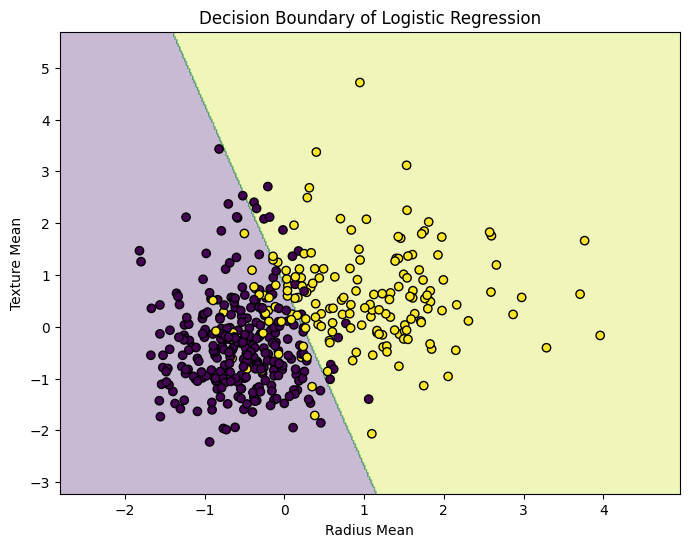

In [7]:
plt.figure(figsize=(8,6))
plt.contourf(xx,yy,Z,alpha=0.3)
plt.scatter(
X_train[:,0],
X_train[:,1],
c=y_train,
edgecolors='k'
)
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("Decision Boundary of Logistic Regression")
plt.show()